<Axes: >

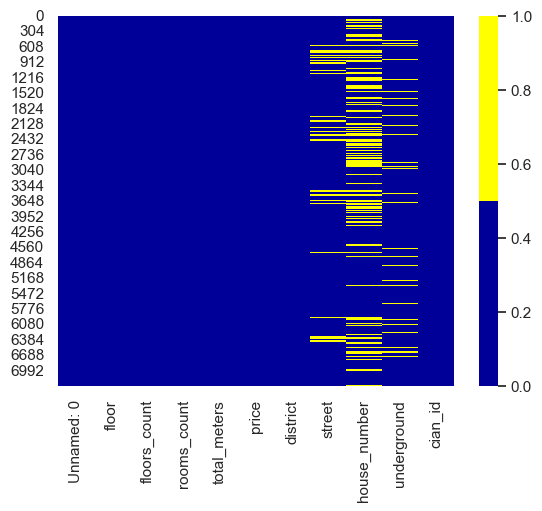

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


sns.set()

df = pd.read_csv('data/flats_modified.csv', )

cols = df.columns
# определяем цвета
# желтый - пропущенные данные, синий - не пропущенные
colours = ['#000099', '#ffff00']
sns.heatmap(df[cols].isnull(), cmap=sns.color_palette(colours))


In [7]:
df['street'].isnull().sum()

654

In [8]:
# получаем все данные с домом и улицей

df_house = df[df.house_number.notna()]
df_house_street = df_house[df['street'].notna()]

df_house_street = df_house_street.drop(['Unnamed: 0'], axis=1)




C:\Users\пк\AppData\Local\Temp\ipykernel_14740\2045864937.py:4: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_house_street = df_house[df['street'].notna()]


In [9]:
df_house_street['adress'] = df_house_street['street'].apply(lambda s: s.strip()) + ' ' + df_house_street['house_number']


In [11]:
from geopy.geocoders import Yandex #Подключаем библиотеку
import tqdm
geolocator = Yandex(user_agent="http", api_key="b98b56ea-e130-4386-b584-68f94a1fe866") #Указываем название приложения (так нужно, да)

# adress = 'Серебристый бульвар 25к2' #Получаем интересующий нас адрес
# location = geolocator.geocode(adress) #Создаем переменную, которая состоит из нужного нам адреса
# print(location) #Выводим результат: адрес в полном виде
# print(location.latitude, location.longitude) #И теперь выводим GPS-координаты нужного нам адреса


# df_ = df_house_street.iloc[:100]

# df_house_street['location'] = df_house_street['adress'].apply(lambda s: geolocator.geocode(s))

# print(geolocator.geocode(df_house_street.iloc[0]['adress']))

lst = []
del_list = []


for row in tqdm.tqdm(df_house_street.iloc, total=len(df_house_street)):
    try:
        lst.append((row['cian_id'], geolocator.geocode('Санкт-Петербург '+ row['adress'])))
    except:
        del_list.append(row['cian_id'])
        print(row['cian_id'], row['adress'])

# # df_house_street

# print(geolocator.geocode('Санкт-Петербург Белоостровская 12'))






  0%|          | 0/5018 [00:00<?, ?it/s]

 65%|██████▍   | 3242/5018 [07:48<23:43,  1.25it/s]

281569527 Марата 70а-70б


100%|██████████| 5018/5018 [11:26<00:00,  7.30it/s]


In [24]:
max([l[1].latitude for l in lst])

5018

In [26]:
dataframe = pd.DataFrame(lst, columns=['cian_id', 'loc'])

dataframe = dataframe.dropna()

dataframe['longitude'] = dataframe["loc"].apply(lambda s: s.longitude)
dataframe['latitude'] = dataframe["loc"].apply(lambda s: s.latitude)


dataframe

,cian_id,loc,longitude,latitude
0,298367029,"(Петровский проспект, 9к2, Санкт-Петербург, Ро...",30.266533,59.960994
1,297442986,"(Байконурская улица, 26, Санкт-Петербург, Росс...",30.279334,60.014603
2,298702714,"(Комендантский проспект, 17к1, Санкт-Петербург...",30.257010,60.011329
3,298588228,"(Ремесленная улица, 17, Санкт-Петербург, Росси...",30.268680,59.957305
4,293435902,"(11-я линия Васильевского острова, 56, Санкт-П...",30.269407,59.944301
...,...,...,...,...
5012,298100864,"(Полевая Сабировская улица, 47к1, Санкт-Петерб...",30.273881,59.996704
5013,299127926,"(Союзный проспект, 4, Санкт-Петербург, Россия,...",30.439557,59.916288
5014,298806561,"(Русановская улица, 16к3, Санкт-Петербург, Рос...",30.507847,59.867037
5015,293101780,"(Красносельское шоссе, 54к1, территория Горело...",30.151494,59.791341


In [27]:
dataframe = dataframe.drop(['loc'], axis=1)


In [28]:
final_df = df_house_street.merge(dataframe, left_on='cian_id', right_on='cian_id')

final_df


,floor,floors_count,rooms_count,total_meters,price,district,street,house_number,underground,cian_id,adress,longitude,latitude
0,7,9,1,42.30,16835400,Петроградский,Петровский проспект,9к2,Спортивная,298367029,Петровский проспект 9к2,30.266533,59.960994
1,4,25,1,37.00,10500000,Приморский,Байконурская,26,Комендантский проспект,297442986,Байконурская 26,30.279334,60.014603
2,10,16,1,44.00,10000000,Приморский,Комендантский проспект,17к1,Комендантский проспект,298702714,Комендантский проспект 17к1,30.257010,60.011329
3,4,8,1,38.50,17500000,Петроградский,Ремесленная,17,Василеостровская,298588228,Ремесленная 17,30.268680,59.957305
4,6,7,1,65.36,22733515,Василеостровский,11-я Васильевского острова линия,56,Василеостровская,293435902,11-я Васильевского острова линия 56,30.269407,59.944301
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5018,12,25,1,31.20,6200000,Приморский,Полевая Сабировская,47к1,Пионерская,298100864,Полевая Сабировская 47к1,30.273881,59.996704
5019,13,15,1,23.90,5950000,Невский,Союзный проспект,4,Проспект Большевиков,299127926,Союзный проспект 4,30.439557,59.916288
5020,6,23,1,30.40,6150000,Невский,Русановская,16к3,Ломоносовская,298806561,Русановская 16к3,30.507847,59.867037
5021,9,18,1,42.60,6150000,Красносельский,шоссе Красносельское,54к1,Проспект Ветеранов,293101780,шоссе Красносельское 54к1,30.151494,59.791341


In [43]:
max_long = final_df['longitude'].min()

len(final_df)
# print(final_df[final_df['longitude'] == max_long])
# final_df = final_df.drop([1084])

print(max_long)

len(final_df)


final_df.to_csv('data/flats_with_chordsv2.csv')

29.662541


In [47]:
final_df_1 = pd.read_csv('data/flats_with_chords.csv')

# final_df_1 = final_df_1.drop(final_df_1[final_df_1['longitude'] < 0], axis = 1)



In [50]:
final_df_1 = final_df_1[final_df_1['longitude'] > 0]
final_df_1['longitude'].min()

14.21432972499748

In [93]:
from geopy.geocoders import Yandex #Подключаем библиотеку
geolocator = Yandex(user_agent="http", api_key="*****") #Указываем название приложения (так нужно, да)

adress = 'Санкт-Петербург Пионерская 50' #Получаем интересующий нас адрес
location = geolocator.geocode(adress, lang='ru_RU') #Создаем переменную, которая состоит из нужного нам адреса
print(location) #Выводим результат: адрес в полном виде
print(location.latitude, location.longitude) #И теперь выводим GPS-координаты нужного нам адреса

GeocoderInsufficientPrivileges: Non-successful status code 403

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


flats = pd.read_csv('data/flats_with_chordsv2.csv')
flats = flats.drop(['Unnamed: 0'], axis=1)

In [3]:
from geopy.geocoders import Yandex #Подключаем библиотеку
geolocator = Yandex(user_agent="http", api_key="*****") #Указываем название приложения (так нужно, да)

center = geolocator.geocode('Санкт-Петербург Эрмитаж', lang='ru_RU')

center

Location(пристань Эрмитаж, Санкт-Петербург, Россия, (59.94134, 30.312428, 0.0))

In [4]:

print(type(flats['underground'].unique()[4]))

<class 'float'>


In [5]:
subway_dict = {}

for subway in flats['underground'].unique():
    if type(subway) == float:
        continue
    subway_dict[subway] = geolocator.geocode(f'Санкт-Петербург станция метро {subway}', lang='ru_RU')

subway_dict
     
     

{'Спортивная': Location(метро Спортивная, 5 линия, Санкт-Петербург, Россия, (59.95019, 30.288335, 0.0)),
 'Комендантский проспект': Location(метро Комендантский проспект, 5 линия, Санкт-Петербург, Россия, (60.008716, 30.258385, 0.0)),
 'Василеостровская': Location(метро Василеостровская, 3 линия, Санкт-Петербург, Россия, (59.94252, 30.278274, 0.0)),
 'Пионерская': Location(метро Пионерская, 2 линия, Санкт-Петербург, Россия, (60.002517, 30.296671, 0.0)),
 'Новочеркасская': Location(метро Новочеркасская, 4 линия, Санкт-Петербург, Россия, (59.928916, 30.411485, 0.0)),
 'Площадь Мужества': Location(метро Площадь Мужества, 1 линия, Санкт-Петербург, Россия, (59.99971, 30.366614, 0.0)),
 'Ленинский проспект': Location(метро Ленинский проспект, 1 линия, Санкт-Петербург, Россия, (59.850712, 30.268356, 0.0)),
 'Крестовский остров': Location(метро Крестовский остров, 5 линия, Санкт-Петербург, Россия, (59.971821, 30.259553, 0.0)),
 'Балтийская': Location(Санкт-Петербург, Россия, (59.938676, 30.314

In [6]:
distance = []
from geopy.distance import geodesic

for i, x in flats.iterrows():
    if type(x['underground']) == float:
        distance.append(0)
    else:
        dist = geodesic((x['latitude'], x['longitude']), (subway_dict[x['underground']].latitude, subway_dict[x['underground']].longitude)).meters
        distance.append(1/dist)


In [7]:
flats['distance_to_subway'] = distance

In [8]:
distance_to_center = []

for i, x in flats.iterrows():
   distance_to_center.append(geodesic((x['latitude'], x['longitude']), (center.latitude, center.longitude)).meters)

max(distance_to_center)


45979.087033098025

In [9]:
flats['distance_to_center'] = distance_to_center

In [10]:
flats.loc[(flats['distance_to_subway'] < 1/5000) & (flats['distance_to_subway'] != 0)]

,floor,floors_count,rooms_count,total_meters,price,district,street,house_number,underground,cian_id,adress,longitude,latitude,distance_to_subway,distance_to_center
10,12,25,1,40.00,6890000,Красносельский,Ленинский проспект,51,Ленинский проспект,299378118,Ленинский проспект 51,30.167305,59.862569,0.000172,11957.448965
18,1,13,1,36.30,6100000,Красносельский,Летчика Лихолетова,14к2,Проспект Ветеранов,298375223,Летчика Лихолетова 14к2,30.105312,59.843290,0.000121,15929.967683
19,2,9,1,29.11,7535060,Красносельский,Тамбасова,5,Проспект Ветеранов,298331096,Тамбасова 5,30.154432,59.841401,0.000183,14219.929287
20,3,4,1,29.60,4913600,Красносельский,Стрельнинское шоссе,3а,Ленинский проспект,297719432,Стрельнинское шоссе 3а,30.084839,59.777759,0.000076,22243.611344
22,7,12,1,32.20,7600000,Приморский,Озеро Долгое,15к3,Старая Деревня,272257905,Озеро Долгое 15к3,30.109750,59.714364,0.000032,27725.038665
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4969,4,4,1,24.70,5600000,Красносельский,проспект Ветеранов,210,Проспект Ветеранов,299641512,проспект Ветеранов 210,30.101494,59.837137,0.000118,16560.137543
4974,3,5,1,28.40,5600000,Московский,Пулковское шоссе,95к4,Проспект Ветеранов,298689188,Пулковское шоссе 95к4,30.305052,59.756115,0.000100,20640.005498
4995,21,21,1,28.60,5850000,Красносельский,проспект Героев,27к1,Ленинский проспект,295995211,проспект Героев 27к1,30.159103,59.861141,0.000160,12388.234523
4999,1,4,1,24.60,5900000,Красносельский,проспект Ветеранов,196,Проспект Ветеранов,292050811,проспект Ветеранов 196,30.112903,59.835166,0.000128,16270.027878


In [11]:
flats['distance_to_subway'].loc[flats['distance_to_subway'] < 1/5000] = 0




C:\Users\пк\AppData\Local\Temp\ipykernel_15312\152927005.py:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  flats['distance_to_subway'].loc[flats['distance_to_subway'] < 1/5000] = 0
C:\Users\пк\AppData\Local\Temp\ipykernel_15312\152927005.p

In [12]:
print(flats['district'].unique())

flats[flats['district'] == 'Супер квартира  Фрунзенский е.3-комн. квартира'] #1896
flats[flats['district'] == 'Супер локация в Петроградском 2-комн. квартира'] #1127

flats = flats.drop([1896, 1127], axis=0)



['Петроградский' 'Приморский' 'Василеостровский' 'Выборгский'
 'Красногвардейский' 'Красносельский' 'Адмиралтейский' 'Курортный'
 'Московский' 'Калининский' 'Петродворцовый' 'Пушкинский' 'Невский'
 'Фрунзенский' 'Кировский' 'Центральный' 'Колпинский'
 'Супер локация в Петроградском 2-комн. квартира'
 'Супер квартира  Фрунзенский е.3-комн. квартира' 'Кронштадтский']


In [13]:
avg_prices = dict(flats.groupby('district')['price'].mean())
avg_prices_sorted = sorted([(x, y) for x, y in avg_prices.items()], key=lambda x: x[1])
print(avg_prices_sorted)
avg_regions = [x[0] for x in avg_prices_sorted][::-1]

[('Пушкинский', 8659916.08), ('Кировский', 9038603.24822695), ('Колпинский', 10157189.962962963), ('Невский', 11170740.688372092), ('Фрунзенский', 11615391.289215686), ('Красносельский', 12155450.577702703), ('Кронштадтский', 12850000.0), ('Петродворцовый', 13422257.02), ('Красногвардейский', 13575852.855072463), ('Приморский', 13838162.37124183), ('Калининский', 14410791.314049587), ('Московский', 15027290.458438287), ('Выборгский', 15533602.869565217), ('Курортный', 18366813.3364486), ('Василеостровский', 20162236.776902888), ('Адмиралтейский', 21274742.350553505), ('Центральный', 36192853.0), ('Петроградский', 60568660.01428571)]


In [14]:
ranks = []

for i, x in flats.iterrows():
   ranks.append(avg_regions.index(x['district']) + 1)

flats['district_rank'] = ranks

In [15]:
flats = flats.drop(['district', 'street', 'house_number', 'underground', 'adress', 'longitude', 'latitude'], axis=1)




In [16]:
# #
# flats.to_csv('data/flats_final.csv', index=False)

In [18]:
# flats.to_csv('data/flats_final_with_cian_id.csv')

In [19]:
flats

,floor,floors_count,rooms_count,total_meters,price,cian_id,distance_to_subway,distance_to_center,district_rank
0,7,9,1,42.30,16835400,298367029,0.000584,3372.307870,1
1,4,25,1,37.00,10500000,297442986,0.000746,8368.926394,9
2,10,16,1,44.00,10000000,298702714,0.003322,8389.206553,9
3,4,8,1,38.50,17500000,298588228,0.000577,3023.426569,1
4,6,7,1,65.36,22733515,293435902,0.001873,2427.235425,4
...,...,...,...,...,...,...,...,...,...
5017,12,25,1,31.20,6200000,298100864,0.000701,6533.132317,9
5018,13,15,1,23.90,5950000,299127926,0.000637,7637.302897,15
5019,6,23,1,30.40,6150000,298806561,0.000258,13715.730091,15
5020,9,18,1,42.60,6150000,293101780,0.000000,18988.523523,13
